## Imports

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout, BatchNormalization

In [10]:
%matplotlib inline

In [11]:
print(tf.config.list_physical_devices("GPU"))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Utils

In [12]:
def plot_history(history, title="Model Performance"):
    _, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    ax1.plot(history.history["accuracy"], label="train")
    ax1.plot(history.history["val_accuracy"], label="validation")
    ax1.set_title(f"{title} - Accuracy")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Accuracy")
    ax1.legend()

    ax2.plot(history.history["loss"], label="train")
    ax2.plot(history.history["val_loss"], label="validation")
    ax2.set_title(f"{title} - Loss")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Loss")
    ax2.legend()

    plt.tight_layout()
    plt.show()

In [13]:
def evaluate_model(model, X_test, y_test, title="Evaluation"):
    print(f"\n{title}:")
    y_pred_probs = model.predict(X_test)
    y_pred = (y_pred_probs > 0.5).astype(int)

    print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")

    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

In [14]:
def predict_and_display_samples(model, X_sample, y_true, model_name="Model"):
    print(f"\\n {model_name}")
    
    pred_probs = model.predict(X_sample, verbose=0)
    pred_classes = (pred_probs > 0.5).astype(int)
    
    for i, (prob, pred, true) in enumerate(zip(pred_probs, pred_classes, y_true)):
        status = "Correct" if pred[0] == true else "Incorrect"
        class_label = "Fraud" if true == 1 else "Genuine"
        
        print(f"Sample {i+1} ({class_label}):")
        print(f"  True Class: {true} | Predicted Class: {pred[0]}")
        print(f"  Probability of Fraud: {prob[0]:.4f} -> {status}\\n")

## EDA

In [15]:
data = pd.read_csv("../data/creditcard.csv")

data.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [16]:
data.isnull().sum().max()

0

In [17]:
data["Amount"].value_counts().head()

Amount
1.00     13688
1.98      6044
0.89      4872
9.99      4747
15.00     3280
Name: count, dtype: int64

In [18]:
data["Class"].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

In [19]:
scaler = StandardScaler()
data["Amount"] = scaler.fit_transform(data[["Amount"]])

data = data.drop(["Time"], axis=1)

In [20]:
X = data.drop("Class", axis=1)
y = data["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=101
)

In [21]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((199364, 29), (85443, 29), (199364,), (85443,))

## Model V1 (Baseline)

In [22]:
model_v1 = Sequential()

model_v1.add(Input(shape=(X_train.shape[1],)))

model_v1.add(Dense(16, activation="relu"))
model_v1.add(Dense(8, activation="relu"))
model_v1.add(Dense(1, activation="sigmoid"))

model_v1.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model_v1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 625 (2.44 KB)

 Trainable params: 625 (2.44 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
history_v1 = model_v1.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=5,
    batch_size=256,
    verbose=1,
)

Epoch 1/5
779/779 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.9456 - loss: 0.1926 - val_accuracy: 0.9994 - val_loss: 0.0223
Epoch 2/5
779/779 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.9993 - loss: 0.0121 - val_accuracy: 0.9994 - val_loss: 0.0059
Epoch 3/5
779/779 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9991 - loss: 0.0064 - val_accuracy: 0.9990 - val_loss: 0.0053
Epoch 4/5
779/779 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9991 - loss: 0.0055 - val_accuracy: 0.9992 - val_loss: 0.0041
Epoch 5/5
779/779 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9992 - loss: 0.0051 - val_accuracy: 0.9992 - val_loss: 0.0040


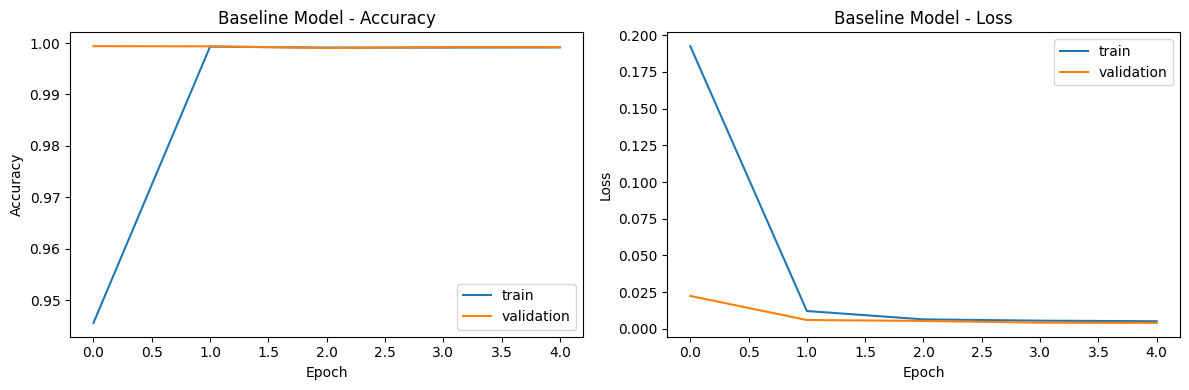


Baseline Model Results:
2671/2671 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
Accuracy Score: 0.9992

Confusion Matrix:
[[85288    11]
 [   55    89]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85299
           1       0.89      0.62      0.73       144

    accuracy                           1.00     85443
   macro avg       0.94      0.81      0.86     85443
weighted avg       1.00      1.00      1.00     85443



In [24]:
plot_history(history_v1, title="Baseline Model")
evaluate_model(model_v1, X_test, y_test, title="Baseline Model Results")

## Model V2 (Class Weights)

In [25]:
weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(weights))

print(f"Class Weights applied: {class_weights}")

Class Weights applied: {0: 0.5008743015636934, 1: 286.4425287356322}


In [26]:
history_v2 = model_v1.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=5,
    batch_size=256,
    class_weight=class_weights,
    verbose=1,
)

Epoch 1/5
779/779 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9809 - loss: 0.3430 - val_accuracy: 0.9803 - val_loss: 0.0781
Epoch 2/5
779/779 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9732 - loss: 0.1971 - val_accuracy: 0.9719 - val_loss: 0.1016
Epoch 3/5
779/779 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9690 - loss: 0.1732 - val_accuracy: 0.9708 - val_loss: 0.1049
Epoch 4/5
779/779 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9678 - loss: 0.1693 - val_accuracy: 0.9756 - val_loss: 0.0987
Epoch 5/5
779/779 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.9689 - loss: 0.1665 - val_accuracy: 0.9729 - val_loss: 0.1047


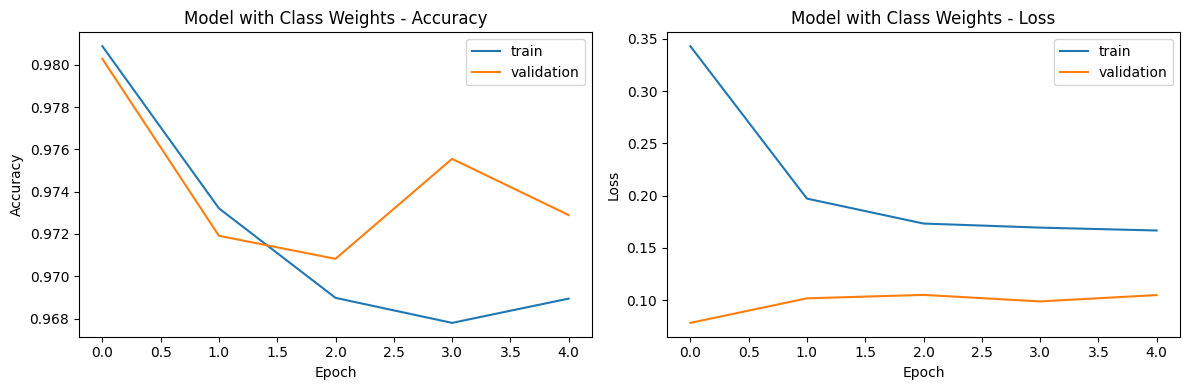


Model with Class Weights:
2671/2671 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step
Accuracy Score: 0.9729

Confusion Matrix:
[[82997  2302]
 [   14   130]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     85299
           1       0.05      0.90      0.10       144

    accuracy                           0.97     85443
   macro avg       0.53      0.94      0.54     85443
weighted avg       1.00      0.97      0.98     85443



In [27]:
plot_history(history_v2, title="Model with Class Weights")
evaluate_model(model_v1, X_test, y_test, title="Model with Class Weights")

In [28]:
non_fraud_samples = X_test[y_test == 0].head(3)
fraud_samples = X_test[y_test == 1].head(3)

X_sample = pd.concat([non_fraud_samples, fraud_samples])
y_sample = pd.concat([y_test[y_test == 0].head(3), y_test[y_test == 1].head(3)])

print(f"{len(X_sample)}")

6


In [29]:
predict_and_display_samples(model_v1, X_sample, y_sample, model_name="Model V2")

\n Model V2
Sample 1 (Genuine):
  True Class: 0 | Predicted Class: 0
  Probability of Fraud: 0.3253 -> Correct\n
Sample 2 (Genuine):
  True Class: 0 | Predicted Class: 0
  Probability of Fraud: 0.0059 -> Correct\n
Sample 3 (Genuine):
  True Class: 0 | Predicted Class: 0
  Probability of Fraud: 0.0067 -> Correct\n
Sample 4 (Fraud):
  True Class: 1 | Predicted Class: 1
  Probability of Fraud: 1.0000 -> Correct\n
Sample 5 (Fraud):
  True Class: 1 | Predicted Class: 1
  Probability of Fraud: 1.0000 -> Correct\n
Sample 6 (Fraud):
  True Class: 1 | Predicted Class: 1
  Probability of Fraud: 1.0000 -> Correct\n


## Model V3 (Improved Architecture)

In [30]:
model_v3 = Sequential()

model_v3.add(Input(shape=(X_train.shape[1],)))

model_v3.add(Dense(64, activation="relu"))
model_v3.add(BatchNormalization())
model_v3.add(Dropout(0.3))

model_v3.add(Dense(32, activation="relu"))
model_v3.add(BatchNormalization())
model_v3.add(Dropout(0.3))

model_v3.add(Dense(16, activation="relu"))
model_v3.add(BatchNormalization())
model_v3.add(Dropout(0.2))

model_v3.add(Dense(1, activation="sigmoid"))

model_v3.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model_v3.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │         1,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16)             │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,993 (19.50 KB)

 Trainable params: 4,769 (18.63 KB)

 Non-trainable params: 224 (896.00 B)

In [31]:
history_v3 = model_v3.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=15,
    batch_size=256,
    class_weight=class_weights,
    verbose=1,
)

Epoch 1/15
779/779 ━━━━━━━━━━━━━━━━━━━━ 26s 30ms/step - accuracy: 0.8079 - loss: 0.3722 - val_accuracy: 0.9622 - val_loss: 0.2200
Epoch 2/15
779/779 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - accuracy: 0.9393 - loss: 0.2093 - val_accuracy: 0.9826 - val_loss: 0.1189
Epoch 3/15
779/779 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.9583 - loss: 0.1994 - val_accuracy: 0.9829 - val_loss: 0.1078
Epoch 4/15
779/779 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.9605 - loss: 0.2016 - val_accuracy: 0.9800 - val_loss: 0.1151
Epoch 5/15
779/779 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.9606 - loss: 0.1926 - val_accuracy: 0.9825 - val_loss: 0.1053
Epoch 6/15
779/779 ━━━━━━━━━━━━━━━━━━━━ 23s 30ms/step - accuracy: 0.9645 - loss: 0.1833 - val_accuracy: 0.9770 - val_loss: 0.1222
Epoch 7/15
779/779 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.9618 - loss: 0.1870 - val_accuracy: 0.9832 - val_loss: 0.1029
Epoch 8/15
779/779 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.9730 - loss: 0.1709 - 

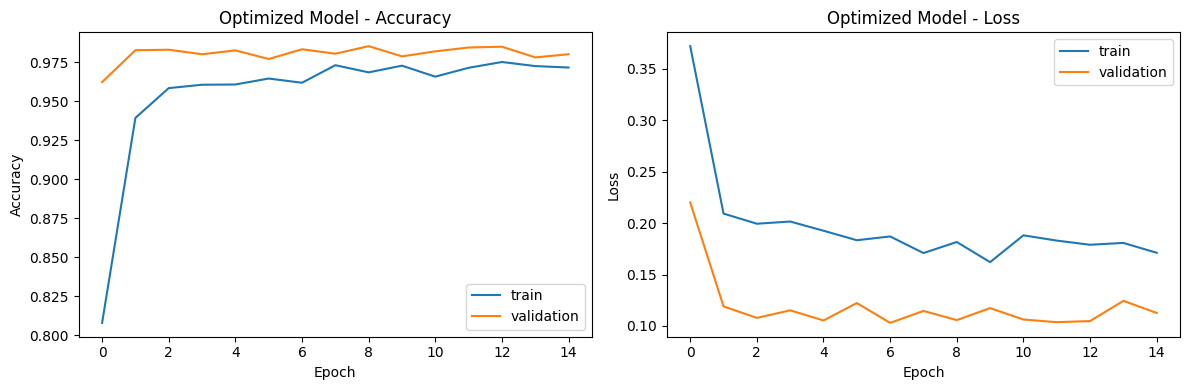


Optimized Model Results:
2671/2671 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step
Accuracy Score: 0.9800

Confusion Matrix:
[[83608  1691]
 [   15   129]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     85299
           1       0.07      0.90      0.13       144

    accuracy                           0.98     85443
   macro avg       0.54      0.94      0.56     85443
weighted avg       1.00      0.98      0.99     85443



In [32]:
plot_history(history_v3, title="Optimized Model")
evaluate_model(model_v3, X_test, y_test, title="Optimized Model Results")

In [33]:
predict_and_display_samples(model_v3, X_sample, y_sample, model_name="Model V3")

\n Model V3
Sample 1 (Genuine):
  True Class: 0 | Predicted Class: 0
  Probability of Fraud: 0.3401 -> Correct\n
Sample 2 (Genuine):
  True Class: 0 | Predicted Class: 0
  Probability of Fraud: 0.0334 -> Correct\n
Sample 3 (Genuine):
  True Class: 0 | Predicted Class: 0
  Probability of Fraud: 0.0195 -> Correct\n
Sample 4 (Fraud):
  True Class: 1 | Predicted Class: 1
  Probability of Fraud: 0.9981 -> Correct\n
Sample 5 (Fraud):
  True Class: 1 | Predicted Class: 1
  Probability of Fraud: 0.9987 -> Correct\n
Sample 6 (Fraud):
  True Class: 1 | Predicted Class: 1
  Probability of Fraud: 0.9999 -> Correct\n
